In [5]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
# read csv file
df=pd.read_csv('clean_real_estate.csv')

In [7]:
df

,price,area_marla,bathroom,bedroom,location,city,area_sqft,price_per_marla
0,20000000.0,4.0,NaN,NaN,Eden Gardens,Faisalabad,1089.000,5.000000e+06
1,80000000.0,13.0,5.0,4.0,Canal Road,Faisalabad,3539.250,6.153846e+06
2,150000000.0,20.0,6.0,5.0,Canal Road,Faisalabad,5445.000,7.500000e+06
3,55000000.0,14.5,5.0,5.0,Canal Road,Faisalabad,3947.625,3.793103e+06
4,85000000.0,11.0,NaN,NaN,Canal Road,Faisalabad,2994.750,7.727273e+06
...,...,...,...,...,...,...,...,...
636,125000000.0,20.0,6.0,5.0,DHA Defence,Islamabad,5445.000,6.250000e+06
637,112200000.0,20.0,6.0,5.0,DHA Defence,Islamabad,5445.000,5.610000e+06
638,280000000.0,20.0,6.0,6.0,F-8,Islamabad,5445.000,1.400000e+07
639,105000000.0,20.0,6.0,5.0,DHA Defence,Islamabad,5445.000,5.250000e+06


In [31]:
df['city'].unique()

array([' Faisalabad', ' Lahore', ' Islamabad'], dtype=object)

In [32]:
df['city']=df['city'].str.strip()

## Analysis

### number of cities

In [33]:
df['city'].value_counts()

,count
city,
Islamabad,233
Faisalabad,215
Lahore,193


### how many houses in each city

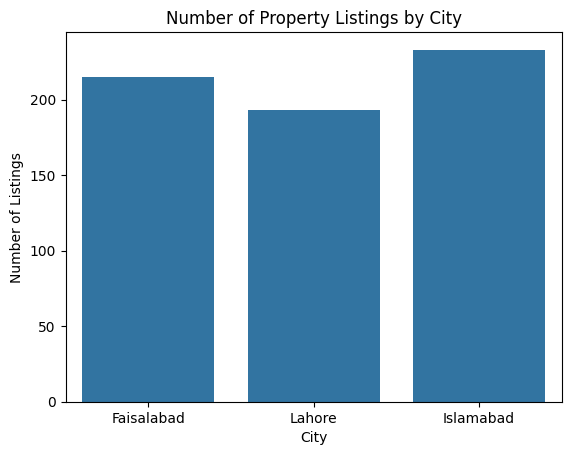

In [34]:
sns.countplot(data=df, x='city')
plt.title('Number of Property Listings by City')
plt.xlabel('City')
plt.ylabel('Number of Listings')
plt.show()

### average property price in each city

In [38]:
df[df['city']=='Faisalabad']['price'].mean()

np.float64(56546046.511627905)

In [39]:
df[df['city']=='Lahore']['price'].mean()

np.float64(69145077.72020726)

In [40]:
df[df['city']=='Islamabad']['price'].mean()

np.float64(129060085.83690988)

### median property price in each city

In [43]:
df.groupby('city')['price'].median()

,price
city,
Faisalabad,32500000.0
Islamabad,81000000.0
Lahore,55000000.0


### average area in marla of property in each city

In [44]:
df.groupby('city')['area_marla'].mean()

,area_marla
city,
Faisalabad,12.712558
Islamabad,15.399571
Lahore,13.108808


### how many bedrooms are most common

In [51]:
df['bedroom'].value_counts().sort_index()

,count
bedroom,
2.0,10
3.0,114
4.0,126
5.0,220
6.0,83
7.0,33
8.0,13
9.0,7
11.0,3


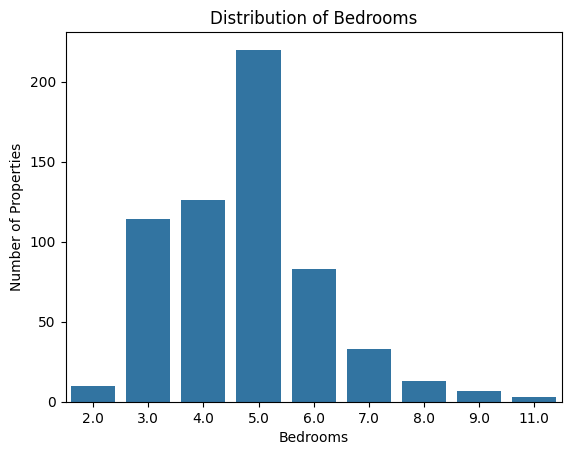

In [52]:
sns.countplot(data=df, x='bedroom')
plt.title('Distribution of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Number of Properties')
plt.show()

### How are property prices distributed

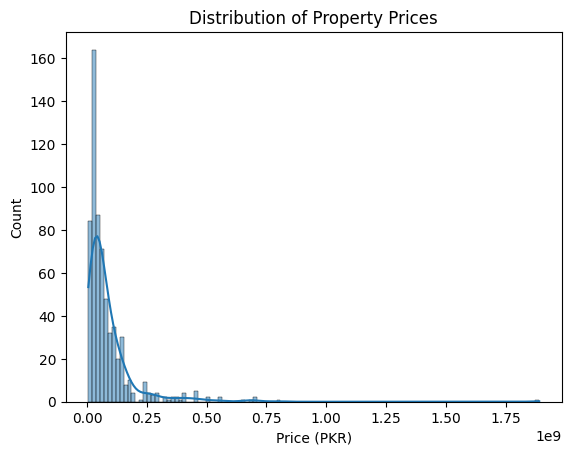

In [55]:
sns.histplot(data=df, x='price', kde=True)
plt.title('Distribution of Property Prices')
plt.xlabel('Price (PKR)')
plt.show()

### which city has highest median price per marla

In [62]:
df.groupby('city')['price'].median().sort_values(ascending=False)

,price
city,
Islamabad,81000000.0
Lahore,55000000.0
Faisalabad,32500000.0


### relationship between property area and price

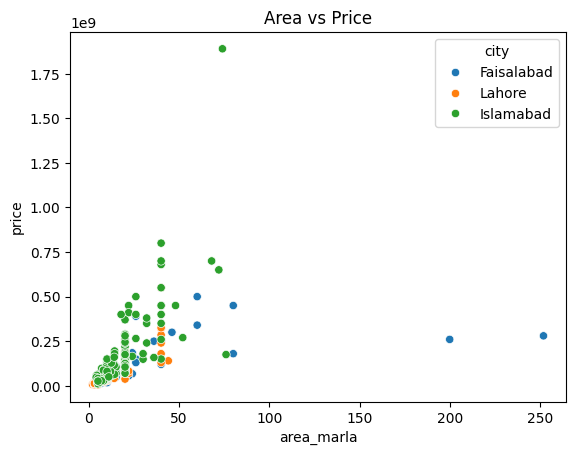

In [71]:
sns.scatterplot(data=df,x='area_marla',y='price',hue='city')
plt.title('Area vs Price')
plt.show()

### average price for different bedroom counts

In [72]:
df.groupby('bedroom')['price'].mean()

,price
bedroom,
2.0,1.448000e+07
3.0,2.605614e+07
4.0,4.135794e+07
5.0,8.506318e+07
6.0,1.643398e+08
7.0,1.866061e+08
8.0,3.503077e+08
9.0,2.366429e+08
11.0,2.316667e+08


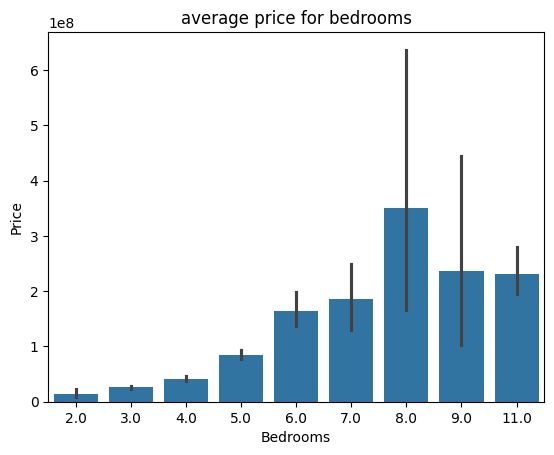

In [76]:
sns.barplot(data=df,x='bedroom',y='price')
plt.title('average price for bedrooms')
plt.ylabel('Price')
plt.xlabel('Bedrooms')
plt.show()

### city has the largest average property area

In [79]:
df.groupby('city')['area_marla'].mean().sort_values(ascending=False)

,area_marla
city,
Islamabad,15.399571
Lahore,13.108808
Faisalabad,12.712558


### What are the most common property sizes

In [82]:
df['area_marla'].value_counts().head(7)

,count
area_marla,
20.0,149
5.0,147
10.0,107
7.0,35
8.0,21
40.0,20
6.0,16


### Which locations in Islamabad have the highest average property prices

In [86]:
df[df['city']=='Islamabad'].groupby('location')['price'].mean().sort_values(ascending=False)

,price
location,
F-6,7.025000e+08
E-7,6.900000e+08
F-7,4.500000e+08
F-8,3.475000e+08
G-6,2.650000e+08
F-10,2.625000e+08
F-11,2.215000e+08
I-8,1.633333e+08
G-9,1.618750e+08


### Which city has the highest price per square foot

In [87]:
df['price_per_spft']=df['price']/df['area_sqft']

In [91]:
df.groupby('city')['price_per_spft'].median().sort_values(ascending=False)

,price_per_spft
city,
Islamabad,22956.841139
Faisalabad,17998.163453
Lahore,17079.889807


### How strongly are area and price correlated

In [93]:
df[['price','area_marla']].corr()

,price,area_marla
price,1.000000,0.563773
area_marla,0.563773,1.000000


### What is the correlation between bedrooms, bathrooms, area, and price

In [94]:
df[['bedroom','bathroom','area_marla','price']].corr()

,bedroom,bathroom,area_marla,price
bedroom,1.000000,0.762218,0.487374,0.489300
bathroom,0.762218,1.000000,0.375648,0.348910
area_marla,0.487374,0.375648,1.000000,0.563773
price,0.489300,0.348910,0.563773,1.000000


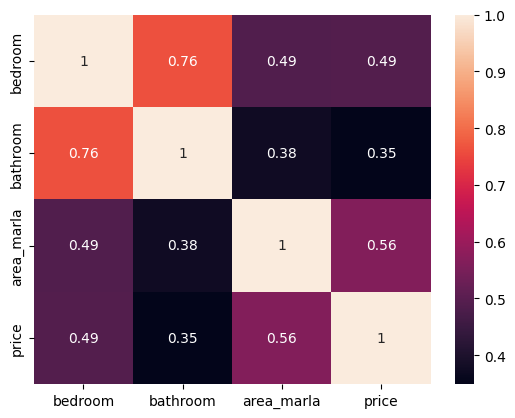

In [97]:
sns.heatmap(df[['bedroom','bathroom','area_marla','price']].corr(),annot=True)
plt.show()

### 10 most expensive properties

In [104]:
df.loc[df['price'].sort_values(ascending=False).head(10).index]

,price,area_marla,bathroom,bedroom,location,city,area_sqft,price_per_marla,price_per_spft
590,1.890000e+09,74.0,6.0,8.0,F-6,Islamabad,20146.5,2.554054e+07,93812.821086
622,8.000000e+08,40.0,NaN,9.0,F-6,Islamabad,10890.0,2.000000e+07,73461.891644
618,7.000000e+08,68.0,6.0,7.0,F-6,Islamabad,18513.0,1.029412e+07,37811.267758
619,7.000000e+08,40.0,6.0,7.0,E-7,Islamabad,10890.0,1.750000e+07,64279.155188
575,6.800000e+08,40.0,6.0,6.0,E-7,Islamabad,10890.0,1.700000e+07,62442.607897
635,6.500000e+08,72.0,6.0,6.0,F-7,Islamabad,19602.0,9.027778e+06,33159.881645
394,5.500000e+08,40.0,7.0,6.0,DHA Defence,Lahore,10890.0,1.375000e+07,50505.050505
621,5.500000e+08,40.0,6.0,6.0,F-6,Islamabad,10890.0,1.375000e+07,50505.050505
591,5.000000e+08,26.0,6.0,7.0,F-7,Islamabad,7078.5,1.923077e+07,70636.434273
19,5.000000e+08,60.0,7.0,8.0,Civil Lines,Faisalabad,16335.0,8.333333e+06,30609.121518


### What are the 10 cheapest properties

In [105]:
df.loc[df['price'].sort_values(ascending=True).head(10).index]

,price,area_marla,bathroom,bedroom,location,city,area_sqft,price_per_marla,price_per_spft
269,5500000.0,5.0,2.0,2.0,Raiwind Road,Lahore,1361.250,1.100000e+06,4040.404040
306,6500000.0,3.0,2.0,2.0,Jubilee Town,Lahore,816.750,2.166667e+06,7958.371595
304,6800000.0,3.0,2.0,2.0,Multan Road,Lahore,816.750,2.266667e+06,8325.681053
283,7500000.0,2.0,2.0,2.0,Qadri Colony,Lahore,544.500,3.750000e+06,13774.104683
568,11000000.0,5.0,3.0,2.0,Bani Gala,Islamabad,1361.250,2.200000e+06,8080.808081
102,11500000.0,2.5,NaN,3.0,Ghalib City,Faisalabad,680.625,4.600000e+06,16896.235078
534,12000000.0,5.0,2.0,2.0,Bani Gala,Islamabad,1361.250,2.400000e+06,8815.426997
183,12000000.0,3.0,4.0,3.0,Kareem City,Faisalabad,816.750,4.000000e+06,14692.378329
325,12500000.0,3.0,3.0,3.0,Raiwind Road,Lahore,816.750,4.166667e+06,15304.560759
184,12500000.0,4.0,4.0,4.0,Gulistan Colony No 1,Faisalabad,1089.000,3.125000e+06,11478.420569


### Which locations have the highest price per Marla

In [108]:
df.groupby('location')['price_per_marla'].median().sort_values(ascending=False).head(12)

,price_per_marla
location,
E-7,1.725000e+07
F-6,1.687500e+07
F-7,1.450000e+07
D-12,1.280000e+07
F-8,1.225000e+07
G-9,1.214160e+07
G-11,1.112500e+07
I-8,1.100000e+07
G-6,1.019231e+07


### city has highest average price per marla

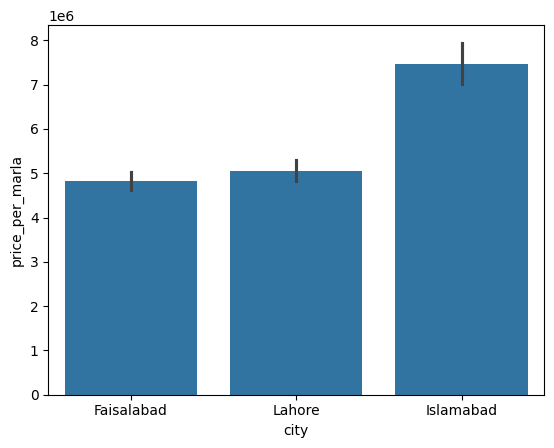

In [111]:
sns.barplot(x=df['city'],y=df['price_per_marla'])
plt.show()

### Does house size affect house price?

Text(0.5, 1.0, 'Size vs Price')

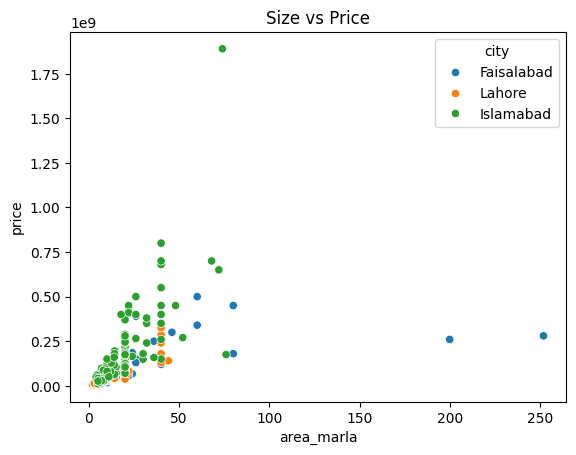

In [112]:
sns.scatterplot(x=df['area_marla'],y=df['price'],hue=df['city'])
plt.title('Size vs Price')